# Raw scanner color characterization

This notebook analyzes raw color differences between scanners using the processed ROI folders containing:

- `roi.vtp` — canonical 3D ROI with embedded RGB and/or UV coordinates
- `geometry.npz` — preprocessing metadata and source texture path
- `qc.png` — visual QC only; **not used for quantitative color analysis**

### Matplotlib fix
The previous error came from a Matplotlib API change. Newer versions use `tick_labels=` in `Axes.boxplot()` instead of `labels=`. This notebook uses the new argument.

The analysis is ROI-level, so scanners with denser meshes do not dominate simply because they contain more vertices.

In [17]:
from pathlib import Path
from itertools import combinations
import re

import numpy as np
import pandas as pd
import pyvista as pv

from PIL import Image

import matplotlib.pyplot as plt

from skimage.color import rgb2lab
from skimage.color import deltaE_ciede2000

from vtk.util.numpy_support import vtk_to_numpy

## 1. Paths and settings

In [18]:
DATA_ROOT = Path(
    r"C:\Users\au662213\repos\biocad3d\data\02-09-2026-Data collected"
)

PROCESSED_ROOT = DATA_ROOT / "_processed_ROI"
OUTPUT_ROOT = DATA_ROOT / "_raw_color_analysis"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

ROI_SUMMARY_FILE = OUTPUT_ROOT / "roi_color_summary.csv"
SCANNER_SUMMARY_FILE = OUTPUT_ROOT / "scanner_color_summary.csv"
PAIRED_FILE = OUTPUT_ROOT / "paired_scanner_differences.csv"

PREFERRED_SCANNER_ORDER = [
    "LABscanner",
    "iTERO",
    "TRIOS3",
    "TRIOS5",
]

# VTK UV coordinates usually use V=0 at bottom, while PIL/NumPy image row 0 is at top.
FLIP_TEXTURE_V = True

SAMPLE_PATTERN = re.compile(
    r"BCG(?P<group>\d+)T(?P<timepoint>\d+)-(?P<sample>\d+)",
    re.IGNORECASE,
)

print("Processed ROI root:", PROCESSED_ROOT)
print("Output root:", OUTPUT_ROOT)

Processed ROI root: C:\Users\au662213\repos\biocad3d\data\02-09-2026-Data collected\_processed_ROI
Output root: C:\Users\au662213\repos\biocad3d\data\02-09-2026-Data collected\_raw_color_analysis


## 2. Helper functions

In [19]:
def npz_scalar_to_python(value):
    array = np.asarray(value)
    if array.ndim == 0:
        return array.item()
    if array.size == 1:
        item = array.reshape(-1)[0]
        try:
            return item.item()
        except AttributeError:
            return item
    return value


def load_geometry_metadata(geometry_file):
    data = np.load(geometry_file, allow_pickle=True)
    metadata = {}
    for key in data.files:
        value = data[key]
        if np.asarray(value).size == 1:
            try:
                value = npz_scalar_to_python(value)
            except Exception:
                pass
        metadata[key] = value
    return metadata


def find_rgb_array(mesh):
    possible_names = [
        "RGB", "rgb", "RGBA", "rgba",
        "Colors", "colors", "Color", "color",
    ]

    for name in possible_names:
        if name not in mesh.point_data:
            continue

        rgb = np.asarray(mesh.point_data[name])
        if not (
            rgb.ndim == 2
            and rgb.shape[0] == mesh.n_points
            and rgb.shape[1] in (3, 4)
        ):
            continue

        rgb = rgb[:, :3]
        if np.issubdtype(rgb.dtype, np.floating):
            rgb = rgb.copy()
            if np.nanmax(rgb) <= 1.0:
                rgb *= 255.0

        rgb = np.clip(rgb, 0, 255).astype(np.uint8)
        return rgb, name

    return None, None


def find_tcoords(mesh):
    possible_names = [
        "TCoords", "tcoords", "Texture Coordinates", "TextureCoordinates",
        "texture_coordinates", "UV", "UVs", "uv", "uvs",
        "TexCoord", "TexCoords", "texcoord", "texcoords",
    ]

    for name in possible_names:
        if name not in mesh.point_data:
            continue

        uv = np.asarray(mesh.point_data[name])
        if uv.ndim == 2 and uv.shape == (mesh.n_points, 2):
            return uv.astype(np.float64), name

    vtk_tcoords = mesh.GetPointData().GetTCoords()
    if vtk_tcoords is not None:
        uv = vtk_to_numpy(vtk_tcoords)
        if uv.ndim == 2 and uv.shape[1] == 2:
            return uv.astype(np.float64), vtk_tcoords.GetName() or "VTK_TCoords"

    return None, None

In [20]:
def bilinear_sample_rgb(image, uv, flip_v=True):
    """Sample an RGB image at UV positions using bilinear interpolation."""
    height, width, _ = image.shape

    u = np.clip(uv[:, 0], 0.0, 1.0)
    v = np.clip(uv[:, 1], 0.0, 1.0)
    if flip_v:
        v = 1.0 - v

    x = u * (width - 1)
    y = v * (height - 1)

    x0 = np.floor(x).astype(int)
    y0 = np.floor(y).astype(int)
    x1 = np.minimum(x0 + 1, width - 1)
    y1 = np.minimum(y0 + 1, height - 1)

    wx = (x - x0)[:, None]
    wy = (y - y0)[:, None]

    image_float = image.astype(np.float64)
    c00 = image_float[y0, x0]
    c10 = image_float[y0, x1]
    c01 = image_float[y1, x0]
    c11 = image_float[y1, x1]

    upper = c00 * (1.0 - wx) + c10 * wx
    lower = c01 * (1.0 - wx) + c11 * wx
    sampled = upper * (1.0 - wy) + lower * wy

    return np.clip(sampled, 0, 255).astype(np.uint8)


def get_roi_rgb(mesh, metadata):
    """
    Color source priority:
      1. embedded RGB
      2. original external texture + ROI UV coordinates
    """
    rgb, rgb_name = find_rgb_array(mesh)
    if rgb is not None:
        return rgb, "embedded_rgb", rgb_name

    uv, uv_name = find_tcoords(mesh)
    if uv is None:
        raise RuntimeError("ROI has neither embedded RGB nor valid UV coordinates.")

    source_texture = str(metadata.get("source_texture", "")).strip()
    if not source_texture:
        raise RuntimeError(
            "UV coordinates exist but geometry.npz contains no source_texture."
        )

    texture_path = Path(source_texture)
    if not texture_path.exists():
        raise FileNotFoundError(f"Source texture does not exist:\n{texture_path}")

    image = np.asarray(Image.open(texture_path).convert("RGB"))
    rgb = bilinear_sample_rgb(image, uv, flip_v=FLIP_TEXTURE_V)

    return rgb, "external_texture", uv_name

In [21]:
def parse_sample_id(sample_id):
    match = SAMPLE_PATTERN.search(str(sample_id))
    if match is None:
        return {
            "group": None,
            "timepoint_number": None,
            "sample_number": None,
            "physical_sample_id": None,
        }

    group = int(match.group("group"))
    timepoint = int(match.group("timepoint"))
    sample_number = int(match.group("sample"))

    return {
        "group": group,
        "timepoint_number": timepoint,
        "sample_number": sample_number,
        "physical_sample_id": f"BCG{group}-{sample_number}",
    }


def calculate_color_statistics(rgb_uint8):
    """Calculate color statistics within one ROI."""
    rgb = rgb_uint8.astype(np.float64) / 255.0
    lab = rgb2lab(rgb.reshape(-1, 1, 3)).reshape(-1, 3)

    L = lab[:, 0]
    a = lab[:, 1]
    b = lab[:, 2]
    chroma = np.sqrt(a**2 + b**2)
    hue = (np.degrees(np.arctan2(b, a)) + 360.0) % 360.0

    R = rgb_uint8[:, 0].astype(float)
    G = rgb_uint8[:, 1].astype(float)
    B = rgb_uint8[:, 2].astype(float)

    values = {"n_color_points": len(rgb_uint8)}

    for name, channel in [("R", R), ("G", G), ("B", B)]:
        values[f"mean_{name}"] = float(np.mean(channel))
        values[f"median_{name}"] = float(np.median(channel))
        values[f"std_{name}"] = float(np.std(channel))

    for name, channel in [("L", L), ("a", a), ("b", b)]:
        values[f"mean_{name}"] = float(np.mean(channel))
        values[f"median_{name}"] = float(np.median(channel))
        values[f"std_{name}"] = float(np.std(channel))
        values[f"p10_{name}"] = float(np.percentile(channel, 10))
        values[f"p90_{name}"] = float(np.percentile(channel, 90))

    values["mean_chroma"] = float(np.mean(chroma))
    values["median_chroma"] = float(np.median(chroma))
    values["median_hue_deg"] = float(np.median(hue))
    values["fraction_near_black"] = float(np.mean(np.max(rgb_uint8, axis=1) <= 5))
    values["fraction_near_white"] = float(np.mean(np.min(rgb_uint8, axis=1) >= 250))

    return values


def discover_processed_rois():
    records = []
    for roi_file in PROCESSED_ROOT.rglob("roi.vtp"):
        geometry_file = roi_file.parent / "geometry.npz"
        if not geometry_file.exists():
            print("Skipping, geometry.npz missing:", roi_file)
            continue
        records.append((roi_file, geometry_file))

    return sorted(records, key=lambda x: str(x[0]).lower())

## 3. Extract raw color statistics from all processed ROIs

In [22]:
roi_files = discover_processed_rois()

print("=" * 80)
print("RAW COLOR CHARACTERIZATION")
print("=" * 80)
print(f"Found {len(roi_files)} processed ROIs.")

rows = []
failures = []

for index, (roi_file, geometry_file) in enumerate(roi_files, start=1):
    try:
        metadata = load_geometry_metadata(geometry_file)
        mesh = pv.read(roi_file)

        sample_id = str(metadata.get("sample_id", roi_file.parent.name))
        scanner = str(metadata.get("scanner", roi_file.parents[2].name))
        parsed = parse_sample_id(sample_id)

        rgb, color_source, color_array = get_roi_rgb(mesh, metadata)
        stats = calculate_color_statistics(rgb)

        row = {
            "scanner": scanner,
            "sample_id": sample_id,
            "physical_sample_id": parsed["physical_sample_id"],
            "group": parsed["group"],
            "timepoint_number": parsed["timepoint_number"],
            "sample_number": parsed["sample_number"],
            "color_source": color_source,
            "color_array_or_uv": color_array,
            "roi_file": str(roi_file),
            "geometry_file": str(geometry_file),
        }
        row.update(stats)
        rows.append(row)

    except Exception as exc:
        failures.append({"roi_file": str(roi_file), "error": str(exc)})
        print(f"FAILED: {roi_file.parent.name}: {exc}")


df = pd.DataFrame(rows)
if df.empty:
    raise RuntimeError("No ROI color data could be extracted.")

df.to_csv(ROI_SUMMARY_FILE, index=False)

print("Successful ROIs:", len(df))
print("Failures:", len(failures))
print("Saved:", ROI_SUMMARY_FILE)

df.head()

RAW COLOR CHARACTERIZATION
Found 200 processed ROIs.
Successful ROIs: 200
Failures: 0
Saved: C:\Users\au662213\repos\biocad3d\data\02-09-2026-Data collected\_raw_color_analysis\roi_color_summary.csv


,scanner,sample_id,physical_sample_id,group,timepoint_number,sample_number,color_source,color_array_or_uv,roi_file,geometry_file,...,mean_b,median_b,std_b,p10_b,p90_b,mean_chroma,median_chroma,median_hue_deg,fraction_near_black,fraction_near_white
0,iTERO,BCG1T0-1,BCG1-1,1,0,1,embedded_rgb,RGB,C:\Users\au662213\repos\biocad3d\data\02-09-20...,C:\Users\au662213\repos\biocad3d\data\02-09-20...,...,20.216262,21.102400,3.662420,14.983291,24.013916,50.127121,49.257104,24.527948,0.0,0.0
1,iTERO,BCG1T0-2,BCG1-2,1,0,2,embedded_rgb,RGB,C:\Users\au662213\repos\biocad3d\data\02-09-20...,C:\Users\au662213\repos\biocad3d\data\02-09-20...,...,17.537864,18.040518,2.883637,13.613639,20.612605,55.746892,55.906563,18.742373,0.0,0.0
2,iTERO,BCG1T0-3,BCG1-3,1,0,3,embedded_rgb,RGB,C:\Users\au662213\repos\biocad3d\data\02-09-20...,C:\Users\au662213\repos\biocad3d\data\02-09-20...,...,21.151333,21.036003,3.709896,16.169115,25.823092,53.303172,53.625898,22.597807,0.0,0.0
3,iTERO,BCG1T0-4,BCG1-4,1,0,4,embedded_rgb,RGB,C:\Users\au662213\repos\biocad3d\data\02-09-20...,C:\Users\au662213\repos\biocad3d\data\02-09-20...,...,17.133048,17.493033,2.148812,14.687186,19.267826,53.266376,53.704315,19.018673,0.0,0.0
4,iTERO,BCG1T0-5,BCG1-5,1,0,5,embedded_rgb,RGB,C:\Users\au662213\repos\biocad3d\data\02-09-20...,C:\Users\au662213\repos\biocad3d\data\02-09-20...,...,19.091480,19.011970,3.252490,14.991532,23.521899,53.536766,52.310233,21.009263,0.0,0.0


## 4. Inspect color source and sample counts

In [23]:
display(
    df.groupby(["scanner", "color_source"])
      .size()
      .rename("n")
      .reset_index()
)

display(
    df.groupby("scanner")
      .size()
      .rename("n_scans")
      .reset_index()
)

,scanner,color_source,n
0,LABscanner,external_texture,56
1,TRIOS3,embedded_rgb,48
2,TRIOS5,embedded_rgb,48
3,iTERO,embedded_rgb,48


,scanner,n_scans
0,LABscanner,56
1,TRIOS3,48
2,TRIOS5,48
3,iTERO,48


## 5. Scanner-level summaries

In [24]:
available_scanners = list(df["scanner"].unique())
scanner_order = [
    scanner for scanner in PREFERRED_SCANNER_ORDER
    if scanner in available_scanners
]
scanner_order += sorted(
    scanner for scanner in available_scanners
    if scanner not in scanner_order
)

summary_variables = [
    "median_R", "median_G", "median_B",
    "median_L", "median_a", "median_b", "median_chroma",
]

scanner_summary_rows = []

for scanner in scanner_order:
    subset = df[df["scanner"] == scanner]
    row = {"scanner": scanner, "n_scans": len(subset)}

    for variable in summary_variables:
        values = subset[variable].dropna().values
        row[f"{variable}_mean"] = float(np.mean(values))
        row[f"{variable}_sd"] = float(np.std(values, ddof=1))
        row[f"{variable}_median"] = float(np.median(values))
        row[f"{variable}_iqr"] = float(
            np.percentile(values, 75) - np.percentile(values, 25)
        )

    scanner_summary_rows.append(row)

scanner_summary = pd.DataFrame(scanner_summary_rows)
scanner_summary.to_csv(SCANNER_SUMMARY_FILE, index=False)

display(scanner_summary)
print("Saved:", SCANNER_SUMMARY_FILE)

,scanner,n_scans,median_R_mean,median_R_sd,median_R_median,median_R_iqr,median_G_mean,median_G_sd,median_G_median,median_G_iqr,...,median_a_median,median_a_iqr,median_b_mean,median_b_sd,median_b_median,median_b_iqr,median_chroma_mean,median_chroma_sd,median_chroma_median,median_chroma_iqr
0,LABscanner,56,194.937500,6.751473,195.5,11.25,107.785714,4.057381,108.0,5.00,...,32.173566,5.641543,25.661709,2.398761,26.159968,3.684293,41.676872,3.690990,41.355708,6.516374
1,iTERO,48,196.031250,6.706940,195.0,7.25,83.885417,14.767431,81.5,26.00,...,45.777725,8.812476,14.410203,3.101445,13.272466,4.782672,48.254508,5.488266,48.743996,9.569600
2,TRIOS3,48,194.083333,3.037590,193.5,3.25,90.333333,10.949271,86.5,21.25,...,43.411130,8.187935,19.952341,2.972083,19.670281,5.237420,46.049464,5.035491,47.684773,10.161602
3,TRIOS5,48,187.385417,4.159377,187.0,4.25,102.895833,12.548187,106.5,24.00,...,34.628094,10.506104,13.475984,3.267477,12.625533,5.822837,36.745526,5.974777,38.372936,11.740539


Saved: C:\Users\au662213\repos\biocad3d\data\02-09-2026-Data collected\_raw_color_analysis\scanner_color_summary.csv


## 6. Paired same-sample scanner comparisons

In [25]:
paired_rows = []

for sample_id, sample_df in df.groupby("sample_id"):
    available = {
        row["scanner"]: row
        for _, row in sample_df.iterrows()
    }

    for scanner_a, scanner_b in combinations(sorted(available.keys()), 2):
        A = available[scanner_a]
        B = available[scanner_b]

        lab_A = np.array([A["median_L"], A["median_a"], A["median_b"]], dtype=float)
        lab_B = np.array([B["median_L"], B["median_a"], B["median_b"]], dtype=float)

        delta_e = float(
            deltaE_ciede2000(
                lab_A.reshape(1, 1, 3),
                lab_B.reshape(1, 1, 3),
            )[0, 0]
        )

        paired_rows.append({
            "sample_id": sample_id,
            "physical_sample_id": A["physical_sample_id"],
            "group": A["group"],
            "timepoint_number": A["timepoint_number"],
            "sample_number": A["sample_number"],
            "scanner_A": scanner_a,
            "scanner_B": scanner_b,
            "scanner_pair": f"{scanner_a} vs {scanner_b}",
            "delta_L": B["median_L"] - A["median_L"],
            "delta_a": B["median_a"] - A["median_a"],
            "delta_b": B["median_b"] - A["median_b"],
            "delta_chroma": B["median_chroma"] - A["median_chroma"],
            "deltaE00_median_color": delta_e,
        })

paired_df = pd.DataFrame(paired_rows)
paired_df.to_csv(PAIRED_FILE, index=False)

print("Saved:", PAIRED_FILE)
display(paired_df.head())

Saved: C:\Users\au662213\repos\biocad3d\data\02-09-2026-Data collected\_raw_color_analysis\paired_scanner_differences.csv


,sample_id,physical_sample_id,group,timepoint_number,sample_number,scanner_A,scanner_B,scanner_pair,delta_L,delta_a,delta_b,delta_chroma,deltaE00_median_color
0,BCG1T0-1,BCG1-1,1,0,1,LABscanner,TRIOS3,LABscanner vs TRIOS3,-8.073220,8.049170,-6.047575,2.771811,10.040833
1,BCG1T0-1,BCG1-1,1,0,1,LABscanner,TRIOS5,LABscanner vs TRIOS5,-0.486623,-2.553020,-10.134881,-8.255010,5.281659
2,BCG1T0-1,BCG1-1,1,0,1,LABscanner,iTERO,LABscanner vs iTERO,-11.506109,8.404377,-9.488567,1.128701,13.989190
3,BCG1T0-1,BCG1-1,1,0,1,TRIOS3,TRIOS5,TRIOS3 vs TRIOS5,7.586597,-10.602190,-4.087306,-11.026821,8.395458
4,BCG1T0-1,BCG1-1,1,0,1,TRIOS3,iTERO,TRIOS3 vs iTERO,-3.432889,0.355207,-3.440992,-1.643110,3.905102


## 7. Boxplots of raw scanner color characteristics

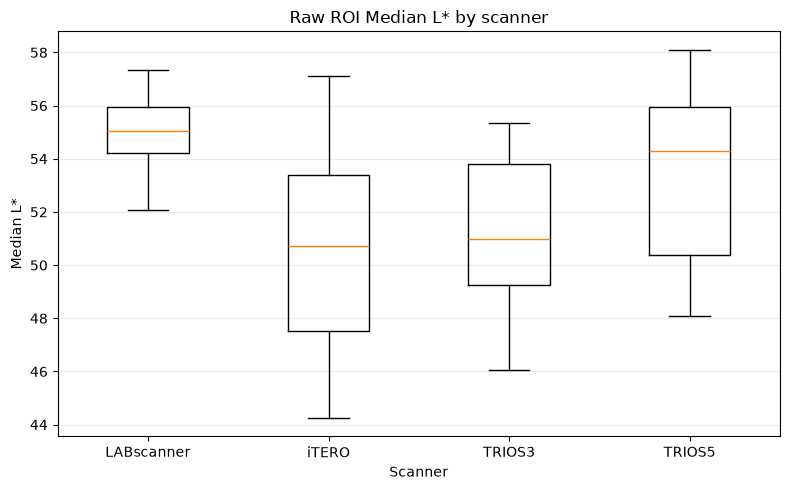

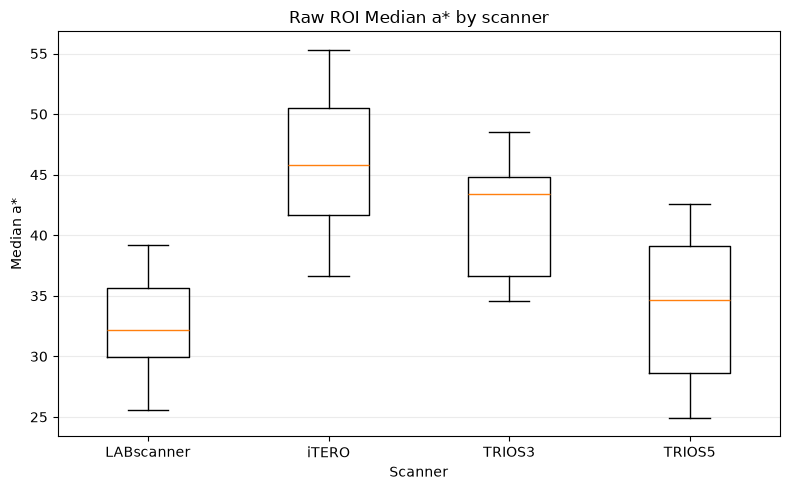

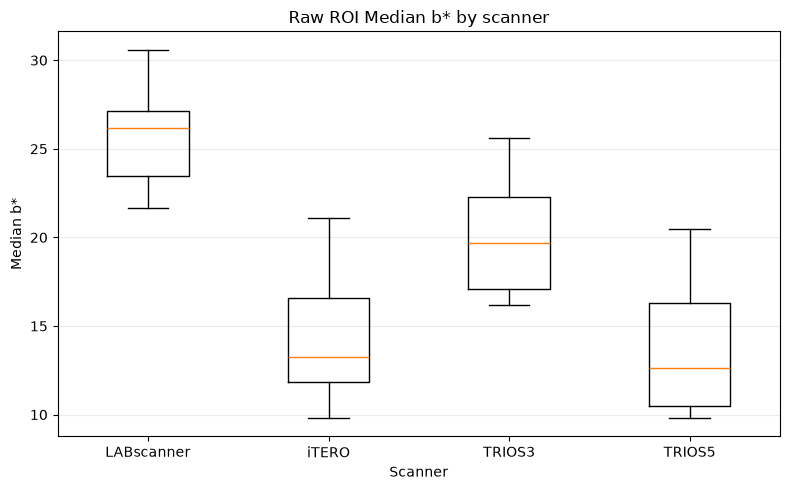

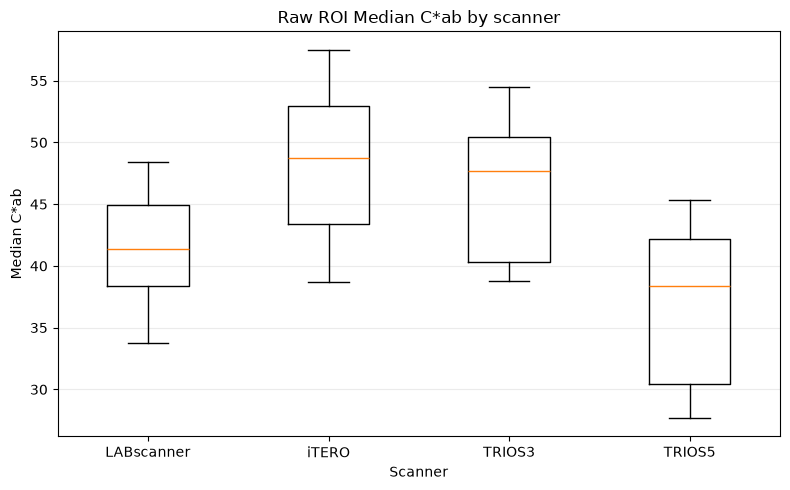

In [26]:
def scanner_boxplot(variable, ylabel, filename=None):
    data = [
        df.loc[df["scanner"] == scanner, variable].dropna().values
        for scanner in scanner_order
    ]

    fig, ax = plt.subplots(figsize=(8, 5))

    # New Matplotlib API: tick_labels, not labels
    ax.boxplot(
        data,
        tick_labels=scanner_order,
        showfliers=True,
    )

    ax.set_xlabel("Scanner")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Raw ROI {ylabel} by scanner")
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()

    if filename is not None:
        fig.savefig(OUTPUT_ROOT / filename, dpi=200)

    plt.show()


scanner_boxplot("median_L", "Median L*", "scanner_Lstar_boxplot.png")
scanner_boxplot("median_a", "Median a*", "scanner_astar_boxplot.png")
scanner_boxplot("median_b", "Median b*", "scanner_bstar_boxplot.png")
scanner_boxplot("median_chroma", "Median C*ab", "scanner_chroma_boxplot.png")

## 8. Paired CIEDE2000 ΔE00 between scanners

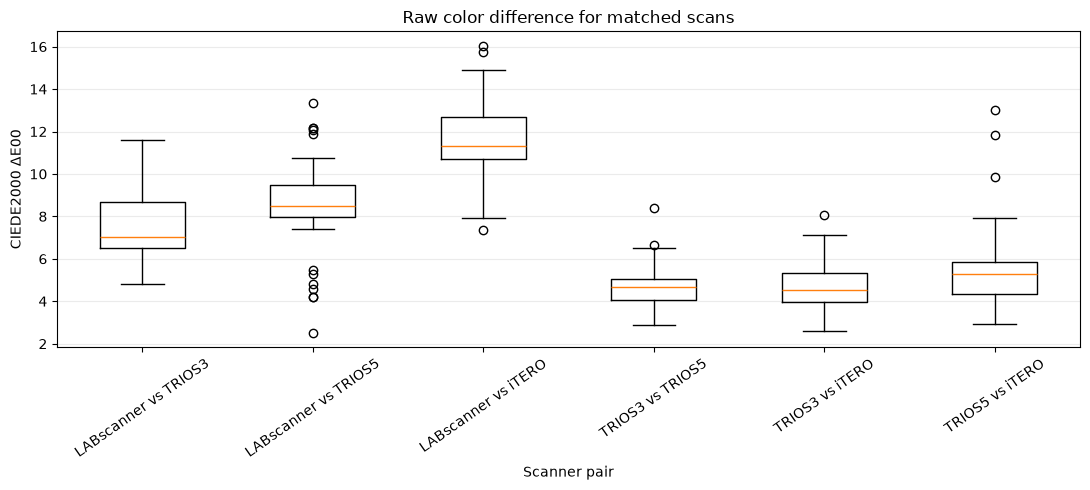

In [27]:
if not paired_df.empty:
    pair_order = sorted(paired_df["scanner_pair"].unique())

    data = [
        paired_df.loc[
            paired_df["scanner_pair"] == pair,
            "deltaE00_median_color",
        ].dropna().values
        for pair in pair_order
    ]

    fig, ax = plt.subplots(figsize=(11, 5))

    # New Matplotlib API: tick_labels, not labels
    ax.boxplot(
        data,
        tick_labels=pair_order,
        showfliers=True,
    )

    ax.set_ylabel("CIEDE2000 ΔE00")
    ax.set_xlabel("Scanner pair")
    ax.set_title("Raw color difference for matched scans")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()

    fig.savefig(
        OUTPUT_ROOT / "paired_scanner_deltaE00_boxplot.png",
        dpi=200,
    )

    plt.show()

## 9. Pairwise median ΔE00 matrix

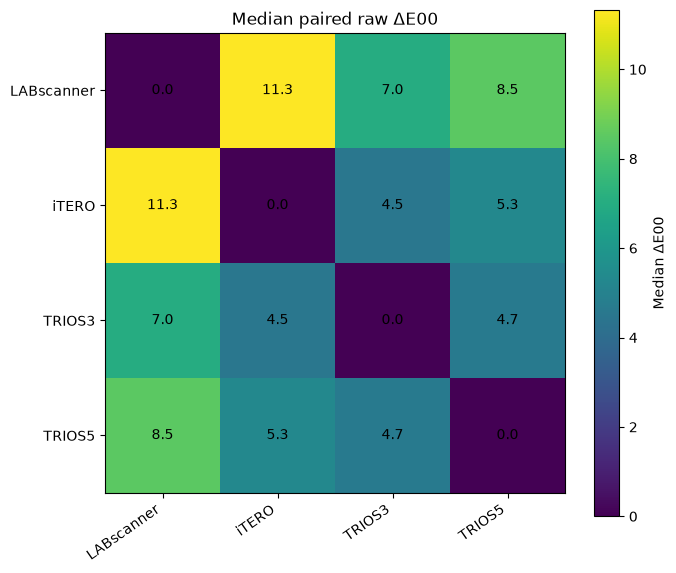

In [28]:
if not paired_df.empty:
    matrix = np.full((len(scanner_order), len(scanner_order)), np.nan)
    np.fill_diagonal(matrix, 0.0)

    for i, scanner_a in enumerate(scanner_order):
        for j, scanner_b in enumerate(scanner_order):
            if j <= i:
                continue

            subset = paired_df[
                (
                    (paired_df["scanner_A"] == scanner_a)
                    & (paired_df["scanner_B"] == scanner_b)
                )
                |
                (
                    (paired_df["scanner_A"] == scanner_b)
                    & (paired_df["scanner_B"] == scanner_a)
                )
            ]

            if subset.empty:
                continue

            value = float(subset["deltaE00_median_color"].median())
            matrix[i, j] = value
            matrix[j, i] = value

    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(matrix)

    ax.set_xticks(np.arange(len(scanner_order)))
    ax.set_yticks(np.arange(len(scanner_order)))
    ax.set_xticklabels(scanner_order, rotation=35, ha="right")
    ax.set_yticklabels(scanner_order)
    ax.set_title("Median paired raw ΔE00")

    for i in range(len(scanner_order)):
        for j in range(len(scanner_order)):
            if np.isfinite(matrix[i, j]):
                ax.text(j, i, f"{matrix[i, j]:.1f}", ha="center", va="center")

    fig.colorbar(image, ax=ax, label="Median ΔE00")
    fig.tight_layout()
    fig.savefig(OUTPUT_ROOT / "paired_scanner_deltaE00_matrix.png", dpi=200)
    plt.show()

## 10. Numerical paired-scanner summary

In [29]:
if not paired_df.empty:
    paired_summary = (
        paired_df.groupby("scanner_pair")[[
            "delta_L",
            "delta_a",
            "delta_b",
            "delta_chroma",
            "deltaE00_median_color",
        ]]
        .agg(["count", "mean", "median", "std"])
    )

    display(paired_summary)

    print("\nMedian paired ΔE00:")
    for pair, subset in paired_df.groupby("scanner_pair"):
        values = subset["deltaE00_median_color"]
        print(
            f"{pair:<30} "
            f"{values.median():6.2f} "
            f"(IQR {values.quantile(0.25):.2f}–{values.quantile(0.75):.2f})"
        )

delta_L                               delta_a             \
                       count      mean    median       std   count       mean   
scanner_pair                                                                    
LABscanner vs TRIOS3      48 -3.348802 -2.076755  2.900690      48   8.492050   
LABscanner vs TRIOS5      48 -1.417157 -0.338505  3.467984      48   1.154801   
LABscanner vs iTERO       48 -4.083550 -4.268647  3.930566      48  13.016706   
TRIOS3 vs TRIOS5          48  1.931645  1.802277  1.644320      48  -7.337249   
TRIOS3 vs iTERO           48 -0.734747 -0.715201  2.259882      48   4.524656   
TRIOS5 vs iTERO           48 -2.666392 -2.440286  2.762866      48  11.861905   

                                          delta_b                        \
                         median       std   count       mean     median   
scanner_pair                                                              
LABscanner vs TRIOS3   8.331295  2.258124      48  -5.557785  -6.244485   
LABscanner vs TRIOS5   0.926343  3.166111      48 -12.034141 -12.672199   
LABscanner vs iTERO   13.108603  3.063090      48 -11.099922 -11.773942   
TRIOS3 vs TRIOS5      -7.733995  2.103490      48  -6.476356  -6.519208   
TRIOS3 vs iTERO        4.419114  1.735210      48  -5.542138  -5.606076   
TRIOS5 vs iTERO       11.876183  2.119123      48   0.934219   1.036908   

                               delta_chroma                                  \
                           std        count       mean     median       std   
scanner_pair                                                                  
LABscanner vs TRIOS3  2.722399           48   4.184194   4.035988  3.061875   
LABscanner vs TRIOS5  2.935242           48  -5.119744  -5.113623  3.452651   
LABscanner vs iTERO   2.889892           48   6.389237   6.594249  3.502936   
TRIOS3 vs TRIOS5      1.242546           48  -9.303938  -9.615968  1.944832   
TRIOS3 vs iTERO       1.360091           48   2.205044   2.234276  1.706252   
TRIOS5 vs iTERO       0.951001           48  11.508982  11.495206  2.085428   

                     deltaE00_median_color                                  
                                     count       mean     median       std  
scanner_pair                                                                
LABscanner vs TRIOS3                    48   7.580650   7.023014  1.595953  
LABscanner vs TRIOS5                    48   8.456757   8.492199  2.155864  
LABscanner vs iTERO                     48  11.729343  11.335091  1.885394  
TRIOS3 vs TRIOS5                        48   4.597295   4.688117  1.058851  
TRIOS3 vs iTERO                         48   4.724823   4.511554  1.052256  
TRIOS5 vs iTERO                         48   5.609897   5.299998  1.911984


Median paired ΔE00:
LABscanner vs TRIOS3             7.02 (IQR 6.50–8.68)
LABscanner vs TRIOS5             8.49 (IQR 7.97–9.48)
LABscanner vs iTERO             11.34 (IQR 10.71–12.70)
TRIOS3 vs TRIOS5                 4.69 (IQR 4.04–5.05)
TRIOS3 vs iTERO                  4.51 (IQR 3.96–5.36)
TRIOS5 vs iTERO                  5.30 (IQR 4.32–5.87)


## 11. Optional: inspect scanner differences by group/timepoint

In [30]:
stage_summary = (
    df.groupby(["scanner", "group", "timepoint_number"])[[
        "median_L",
        "median_a",
        "median_b",
        "median_chroma",
    ]]
    .agg(["count", "median", "mean", "std"])
)

display(stage_summary)

median_L                                  \
                                     count     median       mean       std   
scanner    group timepoint_number                                            
LABscanner 1     0                       8  54.041073  53.984277  1.795284   
                 1                       8  54.234164  54.716876  0.749196   
           2     0                       8  55.941406  55.875556  1.049937   
                 1                       8  56.372292  56.253496  0.710115   
           3     0                       8  55.127888  55.295300  1.098109   
                 1                       8  54.061429  54.033192  0.760821   
                 2                       8  54.791643  55.045360  0.698031   
TRIOS3     1     0                       8  49.190858  49.526064  1.067223   
                 1                       8  54.246436  54.243513  0.580907   
           2     0                       8  49.816134  49.732543  0.390748   
           3     0                       8  48.817381  48.323065  1.313363   
                 1                       8  53.063235  52.747536  0.841191   
                 2                       8  54.256002  54.285026  0.664168   
TRIOS5     1     0                       8  51.630523  52.166202  2.580230   
                 1                       8  56.988099  57.089887  0.462685   
           2     0                       8  50.448819  51.097574  2.063982   
           3     0                       8  49.366209  49.747011  1.330164   
                 1                       8  54.705687  54.439868  0.969937   
                 2                       8  55.754654  55.907074  0.734111   
iTERO      1     0                       8  47.358266  46.775561  1.720215   
                 1                       8  53.528605  54.049751  1.462751   
           2     0                       8  48.302459  48.059721  1.624422   
           3     0                       8  47.690043  48.013240  1.640533   
                 1                       8  53.368274  53.149107  2.171442   
                 2                       8  54.034025  54.401881  1.894836   

                                  median_a                                  \
                                     count     median       mean       std   
scanner    group timepoint_number                                            
LABscanner 1     0                       8  36.346207  36.023716  1.297557   
                 1                       8  29.121326  28.973482  1.602279   
           2     0                       8  34.759410  34.797258  1.185545   
                 1                       8  30.725828  30.287025  1.236807   
           3     0                       8  35.795809  36.106731  1.397622   
                 1                       8  30.924468  31.501402  2.407366   
                 2                       8  30.145592  30.180414  1.483721   
TRIOS3     1     0                       8  44.637455  44.945615  1.071533   
                 1                       8  35.594128  35.496442  0.569317   
           2     0                       8  45.601282  45.525075  0.788765   
           3     0                       8  44.603118  45.141327  1.780886   
                 1                       8  40.746816  40.695817  2.029234   
                 2                       8  36.462122  36.731028  0.974437   
TRIOS5     1     0                       8  37.873965  37.245266  2.002356   
                 1                       8  26.901402  27.032051  1.235517   
           2     0                       8  40.017239  39.930565  1.652481   
           3     0                       8  39.805609  39.745580  0.960871   
                 1                       8  32.067663  31.995677  2.138468   
                 2                       8  28.522044  28.562668  0.930998   
iTERO      1     0                       8  49.145242  49.077370  2.726323   
                 1                       8  38.757623  

## 12. Final output overview

In [31]:
print("=" * 80)
print("FINISHED")
print("=" * 80)

print(f"\nAnalysed ROIs: {len(df)}")

print("\nColor source:")
for source, count in df["color_source"].value_counts().items():
    print(f"  {source:<20} {count}")

print("\nROIs per scanner:")
for scanner in scanner_order:
    count = int(np.sum(df["scanner"] == scanner))
    print(f"  {scanner:<15} {count}")

print(f"\nAll outputs saved to:\n{OUTPUT_ROOT}")

FINISHED

Analysed ROIs: 200

Color source:
  embedded_rgb         144
  external_texture     56

ROIs per scanner:
  LABscanner      56
  iTERO           48
  TRIOS3          48
  TRIOS5          48

All outputs saved to:
C:\Users\au662213\repos\biocad3d\data\02-09-2026-Data collected\_raw_color_analysis
